In [1]:
import sys
sys.path.append("../src")
from linear_foraging import foraging_playground_linear
import numpy as np
from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import seaborn as sns
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state
# from net_utils import set_seed, Trainer
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
session_duration = 1000000
env_name = 'ForagingPlaygroundLinear-v0'
register_custom_env(
    env_name = env_name, 
    map_name = 'short',
    base_reward = 10.0,
    decay_rate = 0.6,
    reward_period = 10,
    session_duration = session_duration
)
env = gym.make(env_name)

base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 1000000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2,1]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

optimal_rewards, optimal_actions = optimal_linear(
    map_name=map_name,
    base_reward=base_reward,
    decay_rate=decay_rate,
    reward_period=reward_period,
    session_duration=session_duration
)

base_reward = 10.0
decay_rate = 0.6
reward_period = 10  
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))



In [3]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_layers=(128, 64), output_dim=1, dropout=0.0):
        super().__init__()
        layers = []
        d = input_dim
        for h in hidden_layers:
            layers += [nn.Linear(d, h), nn.Softplus()]
            # layers += [nn.Linear(d, h)]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = h
        layers += [nn.Linear(d, output_dim)]
        self.net = nn.Sequential(*layers)
        # self.out_act = nn.ReLU()
        self.out_act = nn.Softplus()
        # layers = [
        #     nn.Linear(input_dim, hidden_layers),
        #     nn.ReLU()
        # ]
        # if dropout > 0:
        #     layers.append(nn.Dropout(dropout))
        # layers.append(nn.Linear(hidden_layers, output_dim))
        # self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = self.net(x)
        x = self.out_act(x)
        return x

def standardize_fit_transform(X: np.ndarray):
    X_min = X.min(axis=0, keepdims=True)
    X_max = X.max(axis=0, keepdims=True)
    return (X - X_min) / (X_max-X_min), (X_min, X_max)
    # mean = X.mean(axis=0, keepdims=True)
    # std = X.std(axis=0, keepdims=True)+ 1e-8
    # return (X - mean) /std, (mean, std)

def standardize_transform(X: np.ndarray, stats):
    X_min, X_max = stats
    return (X - X_min) / (X_max - X_min)
    # mean, std = stats
    # return (X - mean) /std

In [24]:
def Trainer(
    X_train: np.ndarray,
    Y_train: np.ndarray,
    hidden_layers=(128, 64),
    lr=1e-3,
    weight_decay=0.0,
    batch_size = 128,
    epochs=50,
    dropout=0.0,
    device: str | None = None,
    standardize_X: bool = False,
):
    """
    Trains an MLP regressor with MSE loss on (X_train, Y_train).
    Returns: (model, X_stats) where X_stats are (mean, std) for transforming future data.
    """
    # Device
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    # Ensure 2D/2D shapes
    X = np.asarray(X_train, dtype=np.float32)
    Y = np.asarray(Y_train, dtype=np.float32)
    if Y.ndim == 1:
        Y = Y[:, None]  # make (n, 1) for single-target

    # Standardize X (common for MLPs)
    if standardize_X:
        # X, X_stats = standardize_fit_transform(X)
        X_stats = (np.zeros((1, X.shape[1]), dtype=np.float32), np.ones((1, X.shape[1]), dtype=np.float32))
        Y, Y_stats = standardize_fit_transform(Y)
        # print(Y)
    else:
        X_stats = (np.zeros((1, X.shape[1]), dtype=np.float32), np.ones((1, X.shape[1]), dtype=np.float32))

    # Torch tensors/dataloader
    X_t = torch.from_numpy(X)
    Y_t = torch.from_numpy(Y)
    ds = TensorDataset(X_t, Y_t)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, drop_last=False)

    # Model / loss / optimizer
    model = MLPRegressor(input_dim=X.shape[1], hidden_layers=hidden_layers, output_dim=Y.shape[1], dropout=dropout)
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for xb, yb in dl:
            xb = xb.to(device)
            yb = yb.to(device)

            preds = model(xb)
            loss = criterion(preds, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item() * xb.size(0)

        epoch_loss /= len(ds)
        # Print optionally
        if epoch % 100 == 0:
            print(f"Epoch {epoch:03d} | MSE: {epoch_loss:.6f}")

    return model, X_stats, device

In [5]:
def best_next_state(X_state, t, model, X_stats, pe_type):
    if X_state == 0:
        candidates = [X_state+1,X_state]
        actions = [2,0]
    elif X_state == 6:
        candidates = [X_state-1,X_state]
        actions = [1,0]
    else:
        candidates = [X_state-1,X_state,X_state+1]
        actions = [1,0,2]
    time_emb = time_embedding_np(t+2, tdim=50)
    preds = []
    for candidate in candidates:
        if pe_type == 'onehot':
            cand_encode = position_encoder(np.array([candidate]), type="onehot")
        if pe_type == 'pe':
            cand_encode = position_encoder(np.array([candidate]), type="pe")
        features = np.hstack([cand_encode, time_emb.reshape(1,-1)])
        features = standardize_transform(features,X_stats)
        features_t = torch.from_numpy(features).to(torch.float32).to(device)
        preds.append(model(features_t).detach().cpu().numpy())
    if len(candidates)==3:
        if preds[0] == preds[1] == preds[2]:
            time_emb2 = time_embedding_np(t+3, tdim=50)
            # best_idx = np.random.choice([0,1,2])
            preds = []
            for cand1 in candidates:
                # generate 2nd‐level candidates at t+2
                if cand1 == 0:
                    cands2 = [cand1+1, cand1]
                elif cand1 == 6:
                    cands2 = [cand1-1, cand1]
                else:
                    cands2 = [cand1-1, cand1, cand1+1]
                preds2 = []
                for cand2 in cands2:
                    if pe_type == 'onehot':
                        cand2_encode = position_encoder(np.array([cand2]), type="onehot")
                    if pe_type == 'pe':
                        cand2_encode = position_encoder(np.array([cand2]), type="pe")
                    feat2 = np.hstack([cand2_encode, time_emb2.reshape(1,-1)])
                    feat2 = standardize_transform(feat2,X_stats)
                    feat2_t = torch.from_numpy(feat2).to(torch.float32).to(device)
                    preds2.append(model(feat2_t).detach().cpu().numpy())
                # best future reward for this branch
                best_scores = np.round(np.max(preds2),10)
                preds.append(best_scores)
            if len(candidates)==3:
                if preds[0] == preds[1] == preds[2]:
                    # print('same')
                    best_idx = 1
                elif preds[1] == preds[0] and preds[1] > preds[2]:
                    # print('same')
                    best_idx = 1
                elif preds[1] == preds[2] and preds[1] > preds[0]:
                    # print('same')
                    best_idx = 1
                else:
                    best_idx = int(np.argmax(preds))
            else:
                best_idx = int(np.argmax(preds))
        elif preds[1] == preds[0] and preds[1] > preds[2]:
            best_idx = 1
        elif preds[1] == preds[2] and preds[1] > preds[0]:
            best_idx = 1
        else:
            best_idx = int(np.argmax(preds))
    elif len(candidates)==2 & (preds[0] == preds[1]):
        # best_idx = np.random.choice([0,1])
        time_emb2 = time_embedding_np(t+3, tdim=50)
        preds = []
        for cand1 in candidates:
            # generate 2nd‐level candidates at t+2
            if cand1 == 0:
                cands2 = [cand1+1, cand1]
            elif cand1 == 6:
                cands2 = [cand1-1, cand1]
            else:
                cands2 = [cand1-1, cand1, cand1+1]
            preds2 = []
            for cand2 in cands2:
                if pe_type == 'onehot':
                    cand2_encode = position_encoder(np.array([cand2]), type="onehot")
                if pe_type == 'pe':
                    cand2_encode = position_encoder(np.array([cand2]), type="pe")
                feat2 = np.hstack([cand2_encode, time_emb2.reshape(1,-1)])
                feat2 = standardize_transform(feat2,X_stats)
                feat2_t = torch.from_numpy(feat2).to(torch.float32).to(device)
                preds2.append(model(feat2_t).detach().cpu().numpy())
            # best future reward for this branch
            best_scores= np.round(np.max(preds2),10)
            preds.append(best_scores)
        best_idx = int(np.argmax(preds))
    else:
        best_idx = int(np.argmax(preds))
    x_best   = candidates[best_idx]
    action = actions[best_idx]
    # print(t,preds)
    return x_best, action

def compute_normalized_future_rewards(rewards,T,gamma):
    Y = np.zeros(T, dtype=float)
    gammas  = gamma ** np.arange(T)  # [γ^0, γ^1, …, γ^{T-1}]

    for t in range(T):
        # number of future steps
        L = T - (t + 1)
        if L <= 0:
            continue

        # normalized weights for the next L rewards
        raw     = gammas[:L]            # [γ^0, γ^1, …, γ^{L-1}]
        weights = raw / raw.sum()

        future_rewards = rewards[t+1 : t+1+L]
        # dot-product returns the weighted average
        Y[t] = np.dot(weights, future_rewards)

    return Y

In [17]:
# Ts = [1000,5000,10000,20000,40000,80000]
Ts = [80000]
for T in Ts:
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                session_duration = 500000,
                                                tdim=50, 
                                                n_sessions=1,seed  = 515)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

    # state_posencode_pe = position_encoder(states[:,0], type="pe")
    # new_state_pe = np.hstack([state_posencode_pe,states[:,1:]])
    print('training timestamps', T)
    prewards = make_weighted_target(irewards, 0.5,T = T)
    X_train = new_state_oh[:T,:]
    Y_train = prewards[:T]

    mlp, X_stats, device = Trainer(
        X_train, Y_train,
        hidden_layers = (256,256,128),  
        lr= 3e-4,
        weight_decay=1e-5,
        batch_size=256,
        epochs=1000,
        dropout=0,
        standardize_X = True
    )

#     x_test = states[T,0]
#     irewards_test = []
#     states_test = []
#     for t_prime in np.arange(0,100):
#         # print(T+t_prime)
#         x_star, action = best_next_state(x_test, T+t_prime, mlp.eval(),X_stats, pe_type= 'onehot')
#         # prev_obs = x_test
#         # next_state, reward, terminated, truncated, info = env.step(action)
#         reward_next  = reward_simulate(x_star,T+t_prime+1,rewards_in_period)
#         # print(x_test,x_star,action,reward_next)
#         x_test = x_star
#         irewards_test.append(reward_next)
#         states_test.append(x_star)
#     # np.savez(
#         # f"/Users/yuxinbai/Desktop/ProspectiveForaging/results/pvfm_pe/PosEncodeNew_onehot_MLP0.5_w_time{T}_reps{0}.npz",
#         # irewards_test=np.array(irewards_test),
#         # states_test=np.array(states_test))
# optimal_rewards_sub = optimal_rewards[T+1 : T + len(irewards_test)+1].copy()
# t_idx = np.arange(1,len(optimal_rewards_sub)+1)
# optimal_rewards_sub[t_idx % 10 >= 6] = 0
# times = np.arange(T+1, T + len(irewards_test)+1)

# # print(optimal_rewards_sub)
# plt.figure(figsize=(8, 3))
# plt.plot(times,irewards_test,label = 'PVFM',alpha = 0.5)
# plt.plot(times,optimal_rewards_sub,label = 'optimal',alpha = 0.5)
# plt.xticks(np.arange(T,T+len(irewards_test),20))
# plt.legend()
# plt.show()

# preward = compute_normalized_future_rewards(irewards_test,100,0.5)
# print('positon - encoding',T,np.sum(preward).item())

training timestamps 80000
Epoch 001 | MSE: 0.022391
Epoch 002 | MSE: 0.015504
Epoch 003 | MSE: 0.015219
Epoch 004 | MSE: 0.014814
Epoch 005 | MSE: 0.014444
Epoch 006 | MSE: 0.014257
Epoch 007 | MSE: 0.014182
Epoch 008 | MSE: 0.014165
Epoch 009 | MSE: 0.014156
Epoch 010 | MSE: 0.014119
Epoch 011 | MSE: 0.014086
Epoch 012 | MSE: 0.014088
Epoch 013 | MSE: 0.014043
Epoch 014 | MSE: 0.013992
Epoch 015 | MSE: 0.013947
Epoch 016 | MSE: 0.013829
Epoch 017 | MSE: 0.013737
Epoch 018 | MSE: 0.013515
Epoch 019 | MSE: 0.013186
Epoch 020 | MSE: 0.012638
Epoch 021 | MSE: 0.012163
Epoch 022 | MSE: 0.011630
Epoch 023 | MSE: 0.011431
Epoch 024 | MSE: 0.011264
Epoch 025 | MSE: 0.011012
Epoch 026 | MSE: 0.010993
Epoch 027 | MSE: 0.010905
Epoch 028 | MSE: 0.010867
Epoch 029 | MSE: 0.010932
Epoch 030 | MSE: 0.010902
Epoch 031 | MSE: 0.010734
Epoch 032 | MSE: 0.010744
Epoch 033 | MSE: 0.010755
Epoch 034 | MSE: 0.010756
Epoch 035 | MSE: 0.010719
Epoch 036 | MSE: 0.010636
Epoch 037 | MSE: 0.010651
Epoch 038 | 

In [18]:
def compute_normalized_future_rewards(rewards,T,gamma):
    Y = np.zeros(T, dtype=float)
    gammas  = gamma ** np.arange(T)  # [γ^0, γ^1, …, γ^{T-1}]

    for t in range(T):
        # number of future steps
        L = T - (t + 1)
        if L <= 0:
            continue

        # normalized weights for the next L rewards
        raw     = gammas[:L]            # [γ^0, γ^1, …, γ^{L-1}]
        weights = raw / raw.sum()

        future_rewards = rewards[t+1 : t+1+L]
        # dot-product returns the weighted average
        Y[t] = np.dot(weights, future_rewards)

    return Y

def get_candidates(state, t):
    if state == 0:
        return [1, 0]
    elif state == 6:
        return [5, 6]
    else:
        # default 3-way split for illustration
        return [state-1, state, state+1]

def enumerate_paths(x0, t_inital = 0, t_prime=20):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df


80000 1.0
Total paths: 482
t=80000    1.0
t=80001    2.0
t=80002    3.0
t=80003    4.0
t=80004    5.0
t=80005    6.0
t=80006    6.0
Name: 481, dtype: float64
[0.15759271 0.15874656 0.0387399  0.01331348 0.01944684 0.02411607
 0.04867759]
80001 2.0
Total paths: 615
t=80001    2.0
t=80002    3.0
t=80003    4.0
t=80004    5.0
t=80005    6.0
t=80006    5.0
t=80007    4.0
Name: 610, dtype: float64
[0.15874656 0.0387399  0.01331348 0.01944684 0.02411607 0.04708961
 0.11167262]
80002 3.0
Total paths: 659
t=80002    3.0
t=80003    4.0
t=80004    5.0
t=80005    6.0
t=80006    5.0
t=80007    4.0
t=80008    4.0
Name: 647, dtype: float64
[0.0387399  0.01331348 0.01944684 0.02411607 0.04708961 0.11167262
 0.18429333]
80003 4.0
Total paths: 615
t=80003    4.0
t=80004    5.0
t=80005    6.0
t=80006    5.0
t=80007    4.0
t=80008    4.0
t=80009    4.0
Name: 584, dtype: float64
[0.01331348 0.01944684 0.02411607 0.04708961 0.11167262 0.18429333
 0.37258688]
80004 5.0
Total paths: 482
t=80004    5.0
t=8000

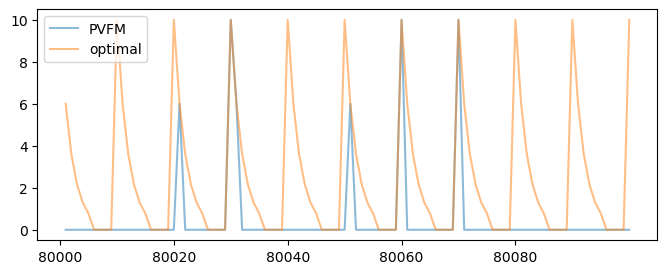

In [22]:
t_prime = 6
current_state = states[T,0]
future_states = [current_state]
irewards_test = []
for delta_t in range(100):
    print(T+delta_t,current_state)
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
    print(f"Total paths: {len(df_all_paths)}")
    n_paths = df_all_paths.shape[0]
    prewards_pred = np.zeros((n_paths, t_prime+1))
    for i in range(t_prime+1):
        cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        features_t = torch.from_numpy(features).to(torch.float32).to(device)
        prewards_pred[:,i] = mlp.eval()(features_t).detach().cpu().numpy().reshape(-1)  
    idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,2,3,4,5,6]])
    best_idx = idx_sorted[-1]
    best_path = df_all_paths.iloc[best_idx,:]
    reward = prewards_pred[best_idx,:]
    print(best_path)
    print(reward)
    next_state = np.array(best_path)[1]
    future_states.append(next_state)
    irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
    current_state = next_state
preward = compute_normalized_future_rewards(irewards_test,len(irewards_test),0.5)
print('positon - encoding',T,np.sum(preward).item())

optimal_rewards_sub = optimal_rewards[T+1 : T + len(irewards_test)+1].copy()
t_idx = np.arange(1,len(optimal_rewards_sub)+1)
optimal_rewards_sub[t_idx % 10 >= 6] = 0
times = np.arange(T+1, T + len(irewards_test)+1)

# print(optimal_rewards_sub)
plt.figure(figsize=(8, 3))
plt.plot(times,irewards_test,label = 'PVFM',alpha = 0.5)
plt.plot(times,optimal_rewards_sub,label = 'optimal',alpha = 0.5)
plt.xticks(np.arange(T,T+len(irewards_test),20))
plt.legend()
plt.show()

training timestamps 320000
Epoch 100 | MSE: 0.010617
Epoch 200 | MSE: 0.010549
Epoch 300 | MSE: 0.010481
Epoch 400 | MSE: 0.010442
Epoch 500 | MSE: 0.010392
Epoch 600 | MSE: 0.010378
Epoch 700 | MSE: 0.010376
Epoch 800 | MSE: 0.010363
Epoch 900 | MSE: 0.010390
Epoch 1000 | MSE: 0.010341
320000 4.0
Total paths: 615
t=320000    4.0
t=320001    4.0
t=320002    5.0
t=320003    6.0
t=320004    6.0
t=320005    6.0
t=320006    6.0
Name: 443, dtype: float64
[0.01455471 0.0099827  0.00856611 0.00823062 0.01186327 0.02612515
 0.04075253]
320001 4.0
Total paths: 615
t=320001    4.0
t=320002    4.0
t=320003    5.0
t=320004    6.0
t=320005    6.0
t=320006    6.0
t=320007    6.0
Name: 443, dtype: float64
[0.0099827  0.00938899 0.00813749 0.01186327 0.02612515 0.04075253
 0.08646517]
320002 4.0
Total paths: 615
t=320002    4.0
t=320003    4.0
t=320004    5.0
t=320005    6.0
t=320006    6.0
t=320007    6.0
t=320008    6.0
Name: 443, dtype: float64
[0.00938899 0.00824614 0.01059158 0.02612515 0.0407525

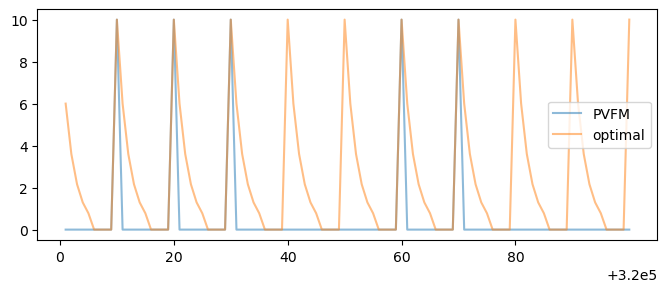

In [30]:
# Ts = [1000,5000,10000,20000,40000,80000,160000]
Ts = [320000]
t_prime = 6
for T in Ts:
    actions, states, irewards, times = simulate_data_raw(rewards_in_period = rewards_in_period,
                                                session_duration = 500000,
                                                tdim=50, 
                                                n_sessions=1,seed  = 515)
    state_posencode_oh = position_encoder(states[:,0], type="onehot")
    new_state_oh = np.hstack([state_posencode_oh,states[:,1:]])

    # state_posencode_pe = position_encoder(states[:,0], type="pe")
    # new_state_pe = np.hstack([state_posencode_pe,states[:,1:]])
    print('training timestamps', T)
    prewards = make_weighted_target(irewards, 0.5,T = T)
    X_train = new_state_oh[:T,:]
    Y_train = prewards[:T]
    if T < 10000:
        batch_size = 64
    elif T < 40000:
        batch_size = 128
    elif T<= 160000:
        batch_size = 256
    else:
        batch_size = 512

    mlp, X_stats, device = Trainer(
        X_train, Y_train,
        hidden_layers = (256,128,256,128),  
        lr= 3e-4,
        weight_decay=1e-5,
        batch_size=batch_size,
        epochs=1000,
        dropout=0,
        standardize_X = True
    )

    
    current_state = states[T,0]
    future_states = [current_state]
    irewards_test = []
    for delta_t in range(100):
        print(T+delta_t,current_state)
        df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime)
        print(f"Total paths: {len(df_all_paths)}")
        n_paths = df_all_paths.shape[0]
        prewards_pred = np.zeros((n_paths, t_prime+1))
        for i in range(t_prime+1):
            cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
            curr_time = T+1+delta_t+i
            time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
            features = np.hstack([cand_pe,time_emb])
            features_t = torch.from_numpy(features).to(torch.float32).to(device)
            prewards_pred[:,i] = mlp.eval()(features_t).detach().cpu().numpy().reshape(-1)  
        idx_sorted = np.lexsort([prewards_pred[:, j] for j in [1,2,3,4,5,6]])
        best_idx = idx_sorted[-1]
        best_path = df_all_paths.iloc[best_idx,:]
        reward = prewards_pred[best_idx,:]
        print(best_path)
        print(reward)
        next_state = np.array(best_path)[1]
        future_states.append(next_state)
        irewards_test.append(reward_simulate(next_state,T+delta_t+1,rewards_in_period))
        current_state = next_state
    np.savez(
        f"/Users/yuxinbai/Desktop/ProspectiveForaging/results/pvfm_lookahead_backward/MLP_onehot_w_time{T}_lookahead_reps{0}.npz",
        # irewards_test=np.array(irewards_test),
        states_test=np.array(future_states))
    preward = compute_normalized_future_rewards(irewards_test,len(irewards_test),0.5)
    print('positon - encoding',T,np.sum(preward).item())

    optimal_rewards_sub = optimal_rewards[T+1 : T + len(irewards_test)+1].copy()
    t_idx = np.arange(1,len(optimal_rewards_sub)+1)
    optimal_rewards_sub[t_idx % 10 >= 6] = 0
    times = np.arange(T+1, T + len(irewards_test)+1)

    # print(optimal_rewards_sub)
    plt.figure(figsize=(8, 3))
    plt.plot(times,irewards_test,label = 'PVFM',alpha = 0.5)
    plt.plot(times,optimal_rewards_sub,label = 'optimal',alpha = 0.5)
    plt.xticks(np.arange(T,T+len(irewards_test),20))
    plt.legend()
    plt.show()

# optimal_rewards_sub = optimal_rewards[T+1 : T + len(irewards_test)+1].copy()
# t_idx = np.arange(1,len(optimal_rewards_sub)+1)
# optimal_rewards_sub[t_idx % 10 >= 6] = 0
# times = np.arange(T+1, T + len(irewards_test)+1)

# # print(optimal_rewards_sub)
# plt.figure(figsize=(8, 3))
# plt.plot(times,irewards_test,label = 'PVFM',alpha = 0.5)
# plt.plot(times,optimal_rewards_sub,label = 'optimal',alpha = 0.5)
# plt.xticks(np.arange(T,T+len(irewards_test),20))
# plt.legend()
# plt.show()

# preward = compute_normalized_future_rewards(irewards_test,100,0.5)
# print('positon - encoding',T,np.sum(preward).item())